# Transparency Index: EDA and modeling

This notebook starts with the index itself, then follows the data into a few small modeling exercises.

The index is calculated for each filing year in the IRS Form 990 data (excluding Form 990-T). The eight non-website components are between 0 and 1 and sum to a score from 0 to 8. A higher score means less measured transparency. Null values after a component calculation are treated as zero, so every refreshed row is complete. Website fields remain in the SQL schema for compatibility, but website collection is disabled and `website_words` remains null. `normalized_index_score` is retained as a compatibility alias for `index_score`.

One qualification matters throughout. The Schedule R measures are derived binary indicators: no qualifying record becomes an observed zero, but that does not prove the filing disclosed every relationship. I therefore report their prevalence separately from component completeness.

## How the score is built

Each factor is scored from 0 to 1. The composite is the sum of all eight factors; higher values indicate lower measured transparency. A ratio with an unavailable denominator produces a null component that is then assigned a zero-value.

1. **Board members** - Form 990 Part I line 4; `1 - min(max(C4 board count, largest same-year related C3 board count), 25) / 25`.
2. **Volunteers** - Form 990 Part I line 6; `1` when reported volunteers are zero and `0` when the organization reports any volunteers.
3. **Related to a 527** - Form 990 Schedule R; `1` when a related 527 organization is identified, otherwise `0`.
4. **Related to a 501(c)(3)** - Form 990 Schedule R; `0` when a related C3 is identified and `1` otherwise.
5. **Political expenses** - Schedule C Part I-A line 1 plus Form 990 Part IX line 11d, divided by total expenses.
6. **Total salaries** - `1 - total salaries / total expenses`, using Form 990 Part I lines 15 and 18.
7. **Unrestricted net assets** - `1 - max(unrestricted net assets, 0) / (3 * total expenses)`, using Form 990 Part X line 27 and Part I line 18.
8. **Fundraising expenses** - `1 - fundraising expenses / grants and contributions`, using Form 990 Part I lines 16b and 9.

All refreshed rows have eight complete components. The classifier, network, clustering, and anomaly sections use the index as an input; they are not extra components.

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DB_PATH = ROOT / "data" / "irs990_full.db"
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

from analysis.modeling import (
    TRANSPARENCY_COMPONENTS,
    analyze_organization_network,
    dbscan_clusters,
    fit_political_activity_classifier,
    isolation_forest_anomalies,
    load_modeling_features,
    transparency_coverage_summary,
)
from extract.transparency_index import INDEX_VERSION

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)
print(f"Database: {DB_PATH}")

Database: /home/mattgroho/github/influence-network/data/irs990_full.db


## 1. Load the index populations

I keep score provenance and raw covariates in the loaded frame. The refreshed source and score snapshots should contain one complete eight-component row for every eligible filing.

In [2]:
all_features = load_modeling_features(
    DB_PATH, complete_only=False, min_observed_components=None
)
complete = all_features

populations = pd.DataFrame(
    [
        {"population": "all scored rows", "rows": len(all_features)},
        {"population": "complete", "rows": len(complete)},
    ]
)
display(populations)
print("Feature contract checks passed.")

,population,rows
0,all scored rows,4366056
1,complete,4366056


Feature contract checks passed.


## 2. A first look at the index

Before fitting anything, I verify that the refreshed rows are complete and inspect the score distribution. The binary relationship fields need a separate prevalence check.

Score run: 20260817T130206127889Z (irvin-8-v1)
SQL source snapshot: 4,366,056 rows


,threshold,rows,coverage_pct
2,8,4366056,100.0


,component,observed_rows,coverage_pct
0,6,4366056,100.0
1,7,4366056,100.0
3,board_members,4366056,100.0
4,volunteers,4366056,100.0
5,related_to_527s,4366056,100.0
6,related_to_c3s,4366056,100.0
7,political_expenses,4366056,100.0
8,total_salaries,4366056,100.0
9,unrestricted_net_assets,4366056,100.0
10,fundraising_expenses,4366056,100.0


,component,scored_rows,identified_rows,identified_pct
0,related_to_527s,4366056,18099,0.41
1,related_to_c3s,4366056,270367,6.19


Relationship scores are derived binary values; 100% score coverage is not relationship prevalence.


,rows
all scored rows,4366056
observed target,610249
unknown target,3755807


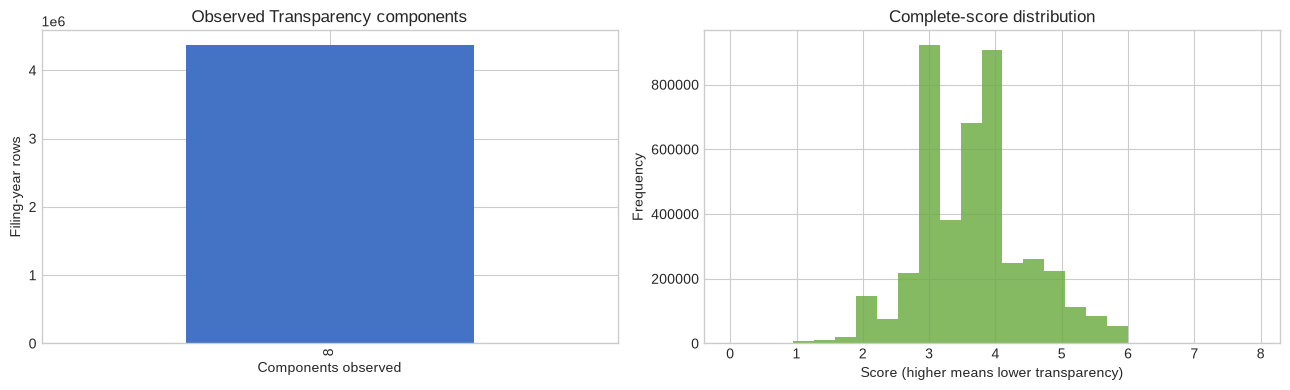

,component,missing_rows,missing_pct
0,board_members,0,0.0
1,volunteers,0,0.0
2,related_to_527s,0,0.0
3,related_to_c3s,0,0.0
4,political_expenses,0,0.0
5,total_salaries,0,0.0
6,unrestricted_net_assets,0,0.0
7,fundraising_expenses,0,0.0


,component,score_1_meaning,score_1_rows,score_1_pct_known,score_0_meaning,score_0_rows,score_0_pct_known,missing_rows
0,related_to_527s,related 527 identified,29417,0.673766,no related 527 identified,4336639,99.326234,0
1,related_to_c3s,no related 501(c)(3) identified,4095689,93.807523,related 501(c)(3) identified,270367,6.192477,0


Relationship components are fully observed because the scoring query treats no qualifying Schedule R record as an observed zero; this is different from missing source data.


,count,mean,std,min,10%,25%,50%,75%,90%,max
index_score,4366056.0,3.654985,0.821555,0.0,2.8,3.0,3.679505,4.0,4.789826,7.894969


,tax_year,rows,median,mean,q25,q75
0,2016,2488,3.863750,3.798601,3.308046,4.149464
1,2017,113053,3.738122,3.684488,3.058309,4.148425
2,2018,477427,3.720000,3.690424,3.000000,4.048922
3,2019,499839,3.711186,3.681399,3.000000,4.041071
4,2020,598971,3.595061,3.605716,3.000000,4.000000
5,2021,451858,3.614572,3.607855,3.000000,4.000000
6,2022,678685,3.679511,3.657641,3.000000,4.000000
7,2023,691984,3.698038,3.670805,3.000000,4.010975
8,2024,665406,3.706734,3.678161,3.000000,4.013987
9,2025,186345,3.624113,3.594979,3.000000,3.981828


,form_type,rows,median,mean
0,990,2278874,3.944762,3.957007
1,990EZ,1326784,3.629986,3.479394
2,990PF,760398,3.000000,3.056219


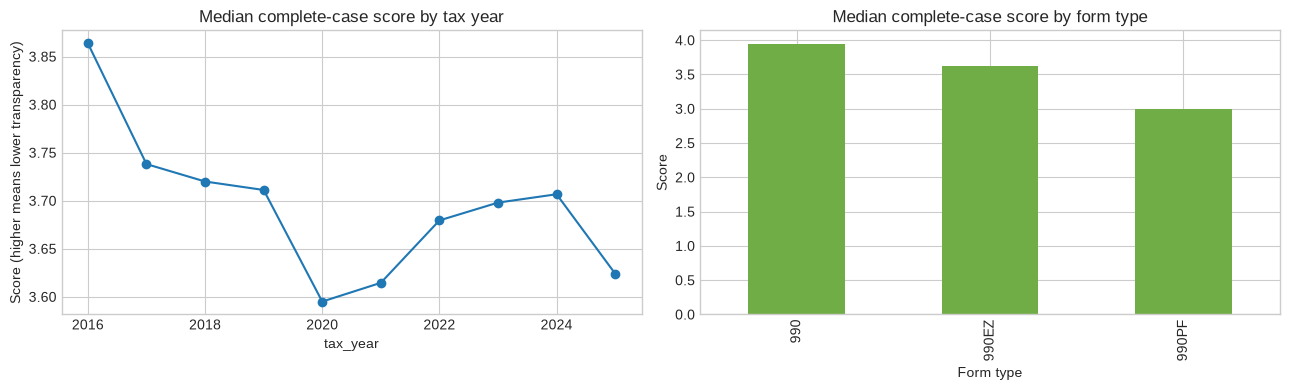

,count,mean,std,min,25%,50%,75%,max
index_score,4366056.0,3.654985,0.821555,0.0,3.0,3.679505,4.0,7.894969
score_without_political,4366056.0,3.653777,0.820367,0.0,3.0,3.678772,4.0,6.984484


,index_score,score_without_political
index_score,1.000000,0.999802
score_without_political,0.999802,1.000000


In [3]:
run_ids = all_features["run_id"].dropna().unique()
assert len(run_ids) == 1, f"Expected one score run, found {len(run_ids)}"
run_id = run_ids[0]
index_version = all_features["index_version"].iloc[0]
assert index_version == INDEX_VERSION == "irvin-8-v1"
print(f"Score run: {run_id} ({index_version})")

with sqlite3.connect(DB_PATH) as connection:
    source_rows = connection.execute(
        "SELECT COUNT(*) FROM transparency_index_source WHERE run_id = ? AND index_version = ?",
        (run_id, index_version),
    ).fetchone()[0]
assert source_rows == len(all_features)
print(f"SQL source snapshot: {source_rows:,} rows")

coverage = transparency_coverage_summary(all_features)
threshold_coverage = coverage.loc[coverage["threshold"].eq(8)].copy()
threshold_coverage["share"] = threshold_coverage["share"].mul(100).round(2)
display(threshold_coverage.rename(columns={"share": "coverage_pct"}))

component_coverage = coverage.loc[~coverage["threshold"].eq(8)].copy()
component_coverage = component_coverage.rename(
    columns={"threshold": "component", "rows": "observed_rows", "share": "coverage_pct"}
)
component_coverage["coverage_pct"] = component_coverage["coverage_pct"].mul(100).round(2)
display(component_coverage)

with sqlite3.connect(DB_PATH) as connection:
    relationship_prevalence = pd.read_sql_query(
        """
        WITH scored AS (
            SELECT s.filing_id,
                   EXISTS (
                       SELECT 1 FROM irs990_filing_related_orgs r
                       WHERE r.filing_id = s.filing_id
                         AND r.entity_type LIKE '%527%'
                   ) AS has_527,
                   EXISTS (
                       SELECT 1 FROM irs990_filing_related_orgs r
                       WHERE r.filing_id = s.filing_id
                         AND r.ein IS NOT NULL
                         AND r.entity_type LIKE '%501%(3)%'
                   ) AS has_c3
            FROM transparency_index_scores s
            WHERE s.run_id = ?
        )
        SELECT 'related_to_527s' AS component,
               COUNT(*) AS scored_rows,
               SUM(has_527) AS identified_rows,
               AVG(has_527) * 100.0 AS identified_pct
        FROM scored
        UNION ALL
        SELECT 'related_to_c3s', COUNT(*), SUM(has_c3), AVG(has_c3) * 100.0
        FROM scored
        """,
        connection,
        params=(run_id,),
    )
relationship_prevalence["identified_pct"] = relationship_prevalence["identified_pct"].round(2)
display(relationship_prevalence)
print("Relationship scores are derived binary values; 100% score coverage is not relationship prevalence.")

target_coverage = pd.DataFrame(
    {
        "rows": [
            len(all_features),
            int(all_features["political_activity_target"].notna().sum()),
            int(all_features["political_activity_target"].isna().sum()),
        ]
    },
    index=["all scored rows", "observed target", "unknown target"],
)
display(target_coverage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
all_features["observed_components"].value_counts().sort_index().plot.bar(
    ax=axes[0], color="#4472c4"
)
axes[0].set_title("Observed Transparency components")
axes[0].set_xlabel("Components observed")
axes[0].set_ylabel("Filing-year rows")
complete["index_score"].plot.hist(
    bins=25, ax=axes[1], color="#70ad47", alpha=0.85
)
axes[1].set_title("Complete-score distribution")
axes[1].set_xlabel("Score (higher means lower transparency)")
plt.tight_layout()
plt.show()

missing_rates = pd.DataFrame({
    "component": list(TRANSPARENCY_COMPONENTS),
    "missing_rows": [
        int(all_features[f"{component}_missing"].sum())
        for component in TRANSPARENCY_COMPONENTS
    ],
})
missing_rates["missing_pct"] = (
    missing_rates["missing_rows"] / len(all_features) * 100
)
display(missing_rates.sort_values("missing_pct", ascending=False))

relationship_score_distribution = []
relationship_semantics = {
    "related_to_527s": (
        "related 527 identified",
        "no related 527 identified",
    ),
    "related_to_c3s": (
        "no related 501(c)(3) identified",
        "related 501(c)(3) identified",
    ),
}
for component, (score_1_meaning, score_0_meaning) in relationship_semantics.items():
    values = all_features[component]
    known = values.notna()
    known_count = int(known.sum())
    score_1_rows = int(values.eq(1).sum())
    score_0_rows = int(values.eq(0).sum())
    relationship_score_distribution.append({
        "component": component,
        "score_1_meaning": score_1_meaning,
        "score_1_rows": score_1_rows,
        "score_1_pct_known": score_1_rows / known_count * 100,
        "score_0_meaning": score_0_meaning,
        "score_0_rows": score_0_rows,
        "score_0_pct_known": score_0_rows / known_count * 100,
        "missing_rows": int((~known).sum()),
    })
display(pd.DataFrame(relationship_score_distribution))
print(
    "Relationship components are fully observed because the scoring query "
    "treats no qualifying Schedule R record as an observed zero; this is "
    "different from missing source data."
)

score_summary = complete[["index_score"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).T
display(score_summary)

score_by_year = (
    complete.groupby("tax_year")["index_score"]
    .agg(
        rows="size",
        median="median",
        mean="mean",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
display(score_by_year)

score_by_form = (
    complete.groupby("form_type")["index_score"]
    .agg(rows="size", median="median", mean="mean")
    .reset_index()
)
display(score_by_form)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
score_by_year.plot(
    x="tax_year", y="median", marker="o", ax=axes[0], legend=False
)
axes[0].set_title("Median complete-case score by tax year")
axes[0].set_ylabel("Score (higher means lower transparency)")
score_by_form.plot.bar(
    x="form_type", y="median", ax=axes[1], legend=False, color="#70ad47"
)
axes[1].set_title("Median complete-case score by form type")
axes[1].set_xlabel("Form type")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

non_political = [
    component
    for component in TRANSPARENCY_COMPONENTS
    if component != "political_expenses"
]
score_sensitivity = complete[["index_score", *non_political]].copy()
score_sensitivity["score_without_political"] = score_sensitivity[non_political].sum(axis=1)
score_columns = ["index_score", "score_without_political"]
display(score_sensitivity[score_columns].describe().T)
display(score_sensitivity[score_columns].corr(method="spearman"))

## 3. Disclosed political-activity classifier

This model predicts disclosed political or lobbying expenditure. Rows without an observable target are left out. I use grouped validation to keep an EIN out of both splits, and a temporal split to see how the model carries into 2024 and later. The target is disclosure, not hidden activity.

,population,rows,target_observed,positive_rate
0,all scored rows,4366056,610249,0.195502
1,complete rows,4366056,610249,0.195502


,rows,positive_rate
tax_year,,
2016,376,0.172872
2017,22865,0.252263
2018,71954,0.210106
2019,74591,0.209167
2020,83744,0.19691
2021,58928,0.186736
2022,93150,0.192163
2023,95286,0.192715
2024,91186,0.190567


,roc_auc,average_precision,brier_score,precision_at_0.5,recall_at_0.5,test_prevalence,average_precision_lift,train_rows,test_rows
validation,,,,,,,,,
grouped,0.919876,0.739055,0.099200,0.610014,0.801673,0.192401,3.841219,458041,152208
2024+ temporal,0.904216,0.684910,0.102534,0.575879,0.740563,0.173700,3.943057,173055,109355


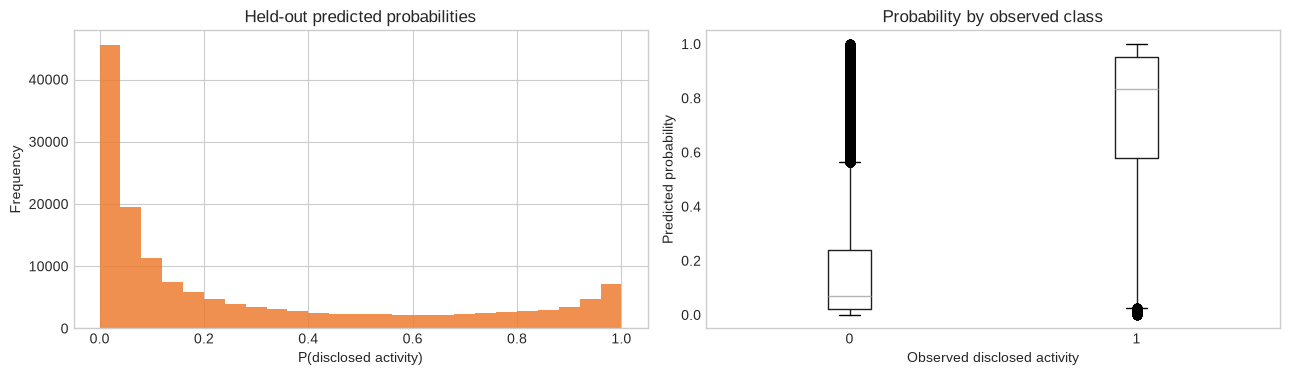

In [4]:
target_observed = all_features["political_activity_target"].notna()
target_summary = pd.DataFrame(
    [
        {
        "population": "all scored rows",
        "rows": len(all_features),
        "target_observed": int(target_observed.sum()),
        "positive_rate": all_features.loc[
            target_observed, "political_activity_target"
        ].mean(),
        },
        {
        "population": "complete rows",
        "rows": len(complete),
        "target_observed": int(
            complete["political_activity_target"].notna().sum()
        ),
        "positive_rate": complete["political_activity_target"].mean(),
        },
    ]
)
display(target_summary)
prevalence_by_year = (
    all_features.loc[target_observed]
    .groupby("tax_year")["political_activity_target"]
    .agg(rows="size", positive_rate="mean")
)
display(prevalence_by_year)
grouped_result = fit_political_activity_classifier(
    all_features, split_strategy="grouped"
)
temporal_result = fit_political_activity_classifier(
    all_features, split_strategy="temporal", test_year=2024
)
classifier_result = grouped_result
model_metrics = pd.DataFrame(
    [
        {
            "validation": "grouped",
            **grouped_result.metrics,
            "train_rows": grouped_result.train_rows,
            "test_rows": grouped_result.test_rows,
        },
        {
            "validation": "2024+ temporal",
            **temporal_result.metrics,
            "train_rows": temporal_result.train_rows,
            "test_rows": temporal_result.test_rows,
        },
    ]
).set_index("validation")
display(model_metrics)

predictions = grouped_result.predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
predictions["predicted_probability"].plot.hist(
    bins=25, ax=axes[0], color="#ed7d31", alpha=0.85
)
axes[0].set_title("Held-out predicted probabilities")
axes[0].set_xlabel("P(disclosed activity)")
predictions.boxplot(
    column="predicted_probability", by="observed", ax=axes[1], grid=False
)
axes[1].set_title("Probability by observed class")
axes[1].set_xlabel("Observed disclosed activity")
axes[1].set_ylabel("Predicted probability")
fig.suptitle("")
plt.tight_layout()
plt.show()




## 4. Organization network analysis

The graph combines grant and related-organization edges, while keeping the two edge types separate in the summaries. Placeholder EINs are excluded. I use this as a way to find records worth reading, not as a causal measure of influence.

,value
nodes,358.00000
edges,278.00000
communities,147.00000
density,0.00435
connected_components,147.00000
largest_component,66.00000
grant_edges,146.00000
related_edges,132.00000
excluded_placeholder_edges,19.00000


,ein,degree,grant_degree,grant_amount,grant_log_strength,related_degree,related_supporting_rows,betweenness,pagerank,community
0,561776668,1,1,1.406805e+10,23.367172,0,0,0.000000,0.002793,12
1,560532129,1,1,1.406805e+10,23.367172,0,0,0.000000,0.002793,12
35,110303001,9,9,1.105896e+10,23.126506,0,0,0.001359,0.009176,2
5,416011702,3,3,1.039609e+10,23.064696,0,0,0.000047,0.005362,6
2,351044585,1,1,9.598521e+09,22.984875,0,0,0.000000,0.002793,13
3,620646012,1,1,9.598521e+09,22.984875,0,0,0.000000,0.002793,13
29,311640316,8,8,8.909712e+09,22.910408,0,0,0.001398,0.007705,2
4,383952644,1,1,8.722142e+09,22.889131,0,0,0.000000,0.001937,6
36,237825575,6,6,8.674964e+09,22.883707,0,0,0.000674,0.005694,2
9,596002052,4,4,8.486343e+09,22.861724,0,0,0.000094,0.006646,4


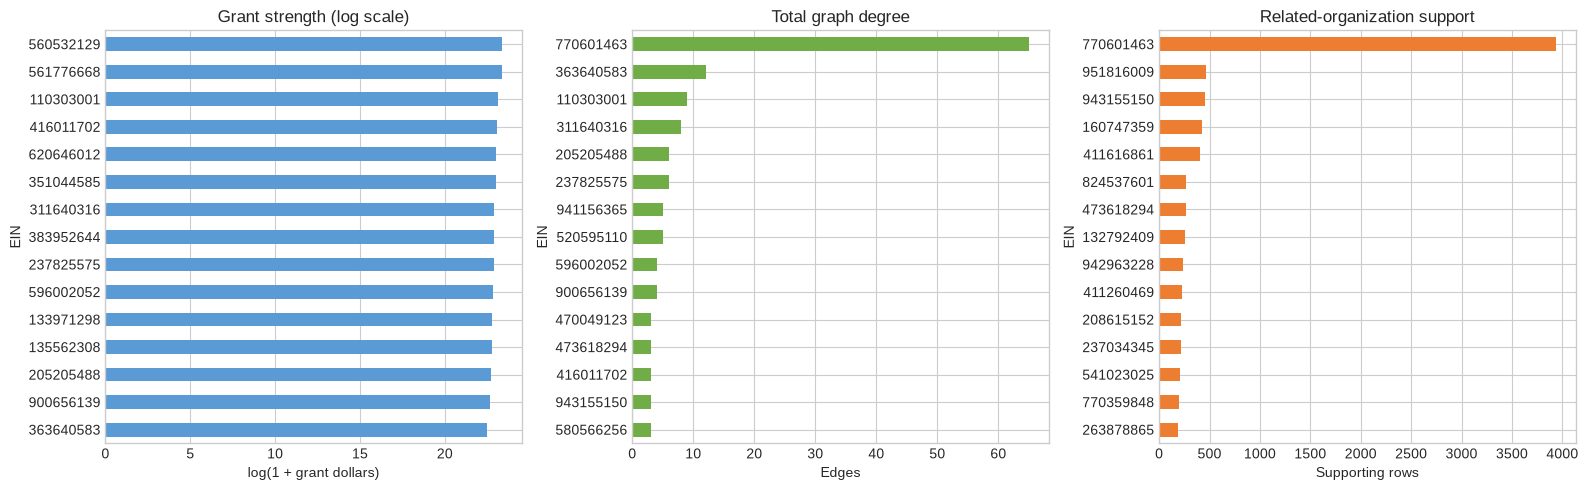

: 

In [ ]:
network_result = analyze_organization_network(DB_PATH, max_edges_per_type=150)
display(pd.Series(network_result.summary, name="value").to_frame())
grant_nodes = network_result.node_features.nlargest(15, "grant_amount")
degree_nodes = network_result.node_features.nlargest(15, "degree")
related_nodes = network_result.node_features.nlargest(15, "related_supporting_rows")
display(grant_nodes)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
grant_nodes.sort_values("grant_log_strength").plot.barh(
    x="ein", y="grant_log_strength", ax=axes[0], legend=False, color="#5b9bd5"
)
axes[0].set_title("Grant strength (log scale)")
axes[0].set_xlabel("log(1 + grant dollars)")
degree_nodes.sort_values("degree").plot.barh(
    x="ein", y="degree", ax=axes[1], legend=False, color="#70ad47"
)
axes[1].set_title("Total graph degree")
axes[1].set_xlabel("Edges")
related_nodes.sort_values("related_supporting_rows").plot.barh(
    x="ein", y="related_supporting_rows", ax=axes[2], legend=False, color="#ed7d31"
)
axes[2].set_title("Related-organization support")
axes[2].set_xlabel("Supporting rows")
for axis in axes:
    axis.set_ylabel("EIN")
plt.tight_layout()
plt.show()

## 5. Unsupervised structure and anomaly review

These two methods are used to make a review list. Their labels are not findings about an organization. The tables below show the highest-ranked rows, the overlap between methods, and the component differences behind the flags.

In [ ]:
matrix = complete[list(TRANSPARENCY_COMPONENTS)].dropna()
cluster_result = dbscan_clusters(
    matrix, eps=1.2, min_samples=5, scale=True
)
anomaly_result = isolation_forest_anomalies(
    matrix, contamination=0.05, n_estimators=100, random_state=42
)
print(
    {
        "rows": len(matrix),
        "clusters": cluster_result.n_clusters,
        "cluster_noise": cluster_result.noise_count,
        "anomalies": anomaly_result.anomaly_count,
    }
)

plot_data = complete.loc[
    matrix.index, ["board_members", "total_salaries"]
].copy()
plot_data["anomaly"] = anomaly_result.labels == -1
fig, ax = plt.subplots(figsize=(8, 5))
for label, group in plot_data.groupby("anomaly"):
    ax.scatter(
        group["board_members"], group["total_salaries"],
        s=22, alpha=0.65, label="anomaly" if label else "regular"
)
ax.set_title("Transparency components with anomaly flags")
ax.set_xlabel("Board-member component")
ax.set_ylabel("Total-salary component")
ax.legend()
plt.tight_layout()
plt.show()

outlier_frame = complete.loc[matrix.index].copy()
outlier_frame["cluster_label"] = cluster_result.labels
outlier_frame["anomaly_score"] = anomaly_result.anomaly_scores
outlier_frame["anomaly_flag"] = anomaly_result.labels == -1
outlier_frame = outlier_frame.sort_values("anomaly_score", ascending=False)
outlier_rows = outlier_frame.loc[outlier_frame["anomaly_flag"]].copy()
outlier_rows["outlier_rank"] = range(1, len(outlier_rows) + 1)
outlier_columns = [
    "outlier_rank", "filing_id", "ein", "tax_year", "filer_name",
    "index_score", "anomaly_score", "cluster_label",
] + list(TRANSPARENCY_COMPONENTS)
print(
    f"Isolation Forest flagged {len(outlier_rows):,} of {len(matrix):,} "
    f"complete rows ({len(outlier_rows) / len(matrix):.1%}); higher anomaly scores "
    "mean greater isolation, not greater misconduct or severity."
)
display(outlier_rows[outlier_columns].head(20))

outlier_overlap = pd.DataFrame({
    "measure": [
        "Isolation Forest flagged",
        "DBSCAN noise",
        "Both methods",
    ],
    "rows": [
        int(outlier_frame["anomaly_flag"].sum()),
        int((outlier_frame["cluster_label"] == -1).sum()),
        int((outlier_frame["anomaly_flag"] & outlier_frame["cluster_label"].eq(-1)).sum()),
    ],
})
outlier_overlap["share_of_complete"] = outlier_overlap["rows"] / len(matrix)
display(outlier_overlap)

overlap_rows = outlier_frame.loc[
    outlier_frame["anomaly_flag"] & outlier_frame["cluster_label"].eq(-1)
].copy()
overlap_rows["overlap_rank"] = range(1, len(overlap_rows) + 1)
overlap_summary = pd.DataFrame({
    "measure": [
        "Overlap rows",
        "Share of Isolation Forest flags",
        "Share of DBSCAN noise",
        "Share of complete rows",
    ],
    "value": [
        str(len(overlap_rows)),
        f"{len(overlap_rows) / len(outlier_rows):.1%}",
        f"{len(overlap_rows) / int((outlier_frame['cluster_label'] == -1).sum()):.1%}",
        f"{len(overlap_rows) / len(matrix):.1%}",
    ],
})
display(overlap_summary)
overlap_columns = [
    "overlap_rank", "filing_id", "ein", "tax_year", "filer_name",
    "index_score", "anomaly_score", "cluster_label",
] + list(TRANSPARENCY_COMPONENTS)
display(overlap_rows[overlap_columns].head(15))

overlap_component_summary = pd.DataFrame({
    "complete_median": matrix.median(),
    "overlap_median": overlap_rows[list(TRANSPARENCY_COMPONENTS)].median(),
})
overlap_component_summary["median_difference"] = (
    overlap_component_summary["overlap_median"]
    - overlap_component_summary["complete_median"]
)
overlap_component_summary["absolute_difference"] = (
    overlap_component_summary["median_difference"].abs()
)
display(
    overlap_component_summary.sort_values(
        "absolute_difference", ascending=False
    ).drop(columns="absolute_difference")
)
overlap_years = (
    overlap_rows["tax_year"]
    .value_counts()
    .sort_index()
    .rename_axis("tax_year")
    .reset_index(name="rows")
)
display(overlap_years)

outlier_component_summary = pd.DataFrame({
    "all_complete_median": matrix.median(),
    "outlier_median": outlier_rows[list(TRANSPARENCY_COMPONENTS)].median(),
    "all_complete_mean": matrix.mean(),
    "outlier_mean": outlier_rows[list(TRANSPARENCY_COMPONENTS)].mean(),
})
display(outlier_component_summary)

## 6. Analysis scope

The notebook covers the index, disclosed political-activity prediction, organization relationships, and unsupervised review candidates. It does not attempt lobbying-text, bill-text, or bill-outcome modeling.

In [ ]:
scope = pd.DataFrame(
    [
        {"analysis": "Transparency Index population", "rows": len(all_features)},
        {"analysis": "Disclosed political-activity classifier", "rows": classifier_result.test_rows},
        {"analysis": "Organization network", "rows": network_result.summary["edges"]},
        {"analysis": "Clustering and anomaly review", "rows": len(matrix)},
    ]
)
display(scope)

## What the current data says

These results use the refreshed score run **20260817T130206127889Z** and index version **irvin-8-v1**. Scores and the source snapshot are loaded from SQLite; Parquet is an optional export.

### Refresh coverage

The refreshed source and score tables each contain **4,366,056 filing-year rows**, covering every eligible filing except Form 990-T. Every row has all eight calculated components, `observed_components = 8`, and `complete = 1`. Website fields remain nullable compatibility columns and are not part of the score; the refresh does not collect or use website data.

### What the index looks like

The score is the unnormalized sum of the eight components, ranging from 0 to 8; higher values indicate lower measured transparency. A null component after calculation is assigned zero, including ratios with zero or unavailable denominators. This keeps the refreshed rows complete without introducing a separate normalization step. Relationship components are derived binary indicators: no qualifying Schedule R record becomes a score of zero or one according to the component definition, but that does not prove that every relationship was disclosed.

The downstream classifier, organization network, clustering, and anomaly sections use the refreshed complete population. Their outputs are descriptive or review aids, not causal evidence about transparency or influence.

### The downstream models are narrower

The classifier target is disclosed political or lobbying expenditure, so rows without an observable target remain excluded from model evaluation. Network, clustering, and anomaly results identify records or structures worth inspecting; they do not establish hidden activity, misconduct, or causal influence.
